In [1]:
# Import thư viện
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Dùng để đọc ảnh và tăng cường dữ liệu
from tensorflow.keras.models import Sequential                       # Mô hình dạng chuỗi các lớp
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW                         # Optimizer hiện đại, tách biệt weight decay
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts # Lịch giảm learning rate
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

2025-10-21 13:41:59.949394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761054120.208918      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761054120.285023      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# === Đường dẫn trên Kaggle ===
train_dir = "/kaggle/input/plantfixed/data/train"
val_dir = "/kaggle/input/plantfixed/data/valid"

In [3]:
# Tăng cường dữ liệu 
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Chuẩn hóa giá trị pixel về [0, 1] giúp mô hình học ổn định hơn
    rotation_range=30,           # Xoay ảnh ngẫu nhiên trong khoảng ±30 độ
    width_shift_range=0.15,      # Dịch ảnh theo chiều ngang 15% kích thước ảnh
    height_shift_range=0.15,     # Dịch ảnh theo chiều dọc 15%                             
    shear_range=0.25,            # Biến dạng xiên hình học (shear transform)
    zoom_range=0.2,              # Phóng to hoặc thu nhỏ ảnh trong khoảng ±20%
    brightness_range=(0.8, 1.2), # Điều chỉnh độ sáng ảnh ngẫu nhiên từ 80% đến 120%
    channel_shift_range=20.0,    # Dịch giá trị của các kênh màu (RGB)
    horizontal_flip=True,        # Lật ảnh theo chiều ngang
    vertical_flip=True,          # Lật ảnh theo chiều dọc  
    fill_mode='nearest'          # Khi xoay, dịch, zoom... các pixel trống sẽ được lấp bằng giá trị gần nhất
)
val_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
# Nạp dữ liệu
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical' # One-hot cho bài phân loại đa lớp
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical'
)

Found 49630 images belonging to 38 classes.
Found 8269 images belonging to 38 classes.


In [5]:
# Xây dựng mô hình CNN 
model = Sequential([
    # Khối 1
    Conv2D(32, (3,3), padding='same', input_shape=(256,256,3)), # 32 bộ lọc 3x3, giữ nguyên kích thước ảnh đầu vào
    BatchNormalization(),                                        # Chuẩn hóa đầu ra giúp tăng tốc hội tụ
    LeakyReLU(alpha=0.1),                                        # Kích hoạt phi tuyến, tránh hiện tượng chết ReLU
    MaxPooling2D(2,2),                                            # Giảm kích thước không gian (downsampling 2x)

    # Khối 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),

    # Khối 3
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),

    # Khối 4
    Conv2D(256, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),

    # Khối 5
    Conv2D(512, (3,3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(2,2),

    # Fully Connected
    GlobalAveragePooling2D(),                            # Tổng hợp đặc trưng không gian thành vector 1D
    Dense(512),                                          # Lớp kết nối đầy đủ với 512 neuron
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),                                        # Giảm overfitting bằng cách bỏ ngẫu nhiên 50% neuron
    Dense(train_gen.num_classes, activation='softmax')   # Lớp đầu ra: softmax → phân loại đa lớp (38 loại bệnh)
])
# Biên dịch mô hình với AdamW
# AdamW là phiên bản cải tiến của Adam, có weight decay để regularize tự động (giúp giảm overfitting)
optimizer = AdamW(learning_rate=1e-4, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
I0000 00:00:1761054145.816528      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
# Callback: Dừng sớm nếu mô hình không còn cải thiện
early_stop = EarlyStopping(
    monitor='val_loss',   # Theo dõi lỗi trên tập validation
    patience=5,           # Nếu sau 5 epoch không giảm nữa thì dừng
    restore_best_weights=True  # Khôi phục lại trọng số tốt nhất
)

# Callback: Giảm learning rate nếu val_loss không cải thiện 
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Giảm LR xuống 1/2
    patience=3,           # Sau 3 epoch không cải thiện sẽ giảm
    min_lr=1e-6           # Không giảm nhỏ hơn mức này
)

# Callback: Lưu mô hình tốt nhất trong quá trình train 
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [7]:
#  Huấn luyện mô hình 
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,             # Tăng số epoch vì có EarlyStopping (tự dừng khi đạt tối ưu)
    callbacks=[early_stop, reduce_lr, checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1761054154.815326     107 service.cc:148] XLA service 0x7f3784107170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761054154.816475     107 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761054155.502004     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/3102 ━━━━━━━━━━━━━━━━━━━━ 11:30:39 13s/step - accuracy: 0.0000e+00 - loss: 4.1242

I0000 00:00:1761054161.544223     107 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3102/3102 ━━━━━━━━━━━━━━━━━━━━ 1224s 390ms/step - accuracy: 0.3106 - loss: 2.6179 - val_accuracy: 0.5769 - val_loss: 1.5867 - learning_rate: 1.0000e-04
Epoch 2/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 1024s 330ms/step - accuracy: 0.6240 - loss: 1.3102 - val_accuracy: 0.6105 - val_loss: 1.3905 - learning_rate: 1.0000e-04
Epoch 3/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 1045s 337ms/step - accuracy: 0.7198 - loss: 0.9543 - val_accuracy: 0.7341 - val_loss: 1.0055 - learning_rate: 1.0000e-04
Epoch 4/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 1031s 332ms/step - accuracy: 0.7679 - loss: 0.7839 - val_accuracy: 0.6726 - val_loss: 1.2781 - learning_rate: 1.0000e-04
Epoch 5/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 1094s 353ms/step - accuracy: 0.8076 - loss: 0.6435 - val_accuracy: 0.7815 - val_loss: 0.7751 - learning_rate: 1.0000e-04
Epoch 6/15
3102/3102 ━━━━━━━━━━━━━━━━━━━━ 1070s 345ms/step - accuracy: 0.8294 - loss: 0.5773 - val_accuracy: 0.8311 - val_loss: 0.5957 - learning_rate: 1.0000e-04
Epoch 7/15
3102/3102 ━━━━━━━━━━━━

In [10]:
# Lưu mô hình
model.save('/kaggle/working/plant_disease_cnn_256.h5')

Found 8269 images belonging to 38 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


517/517 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step


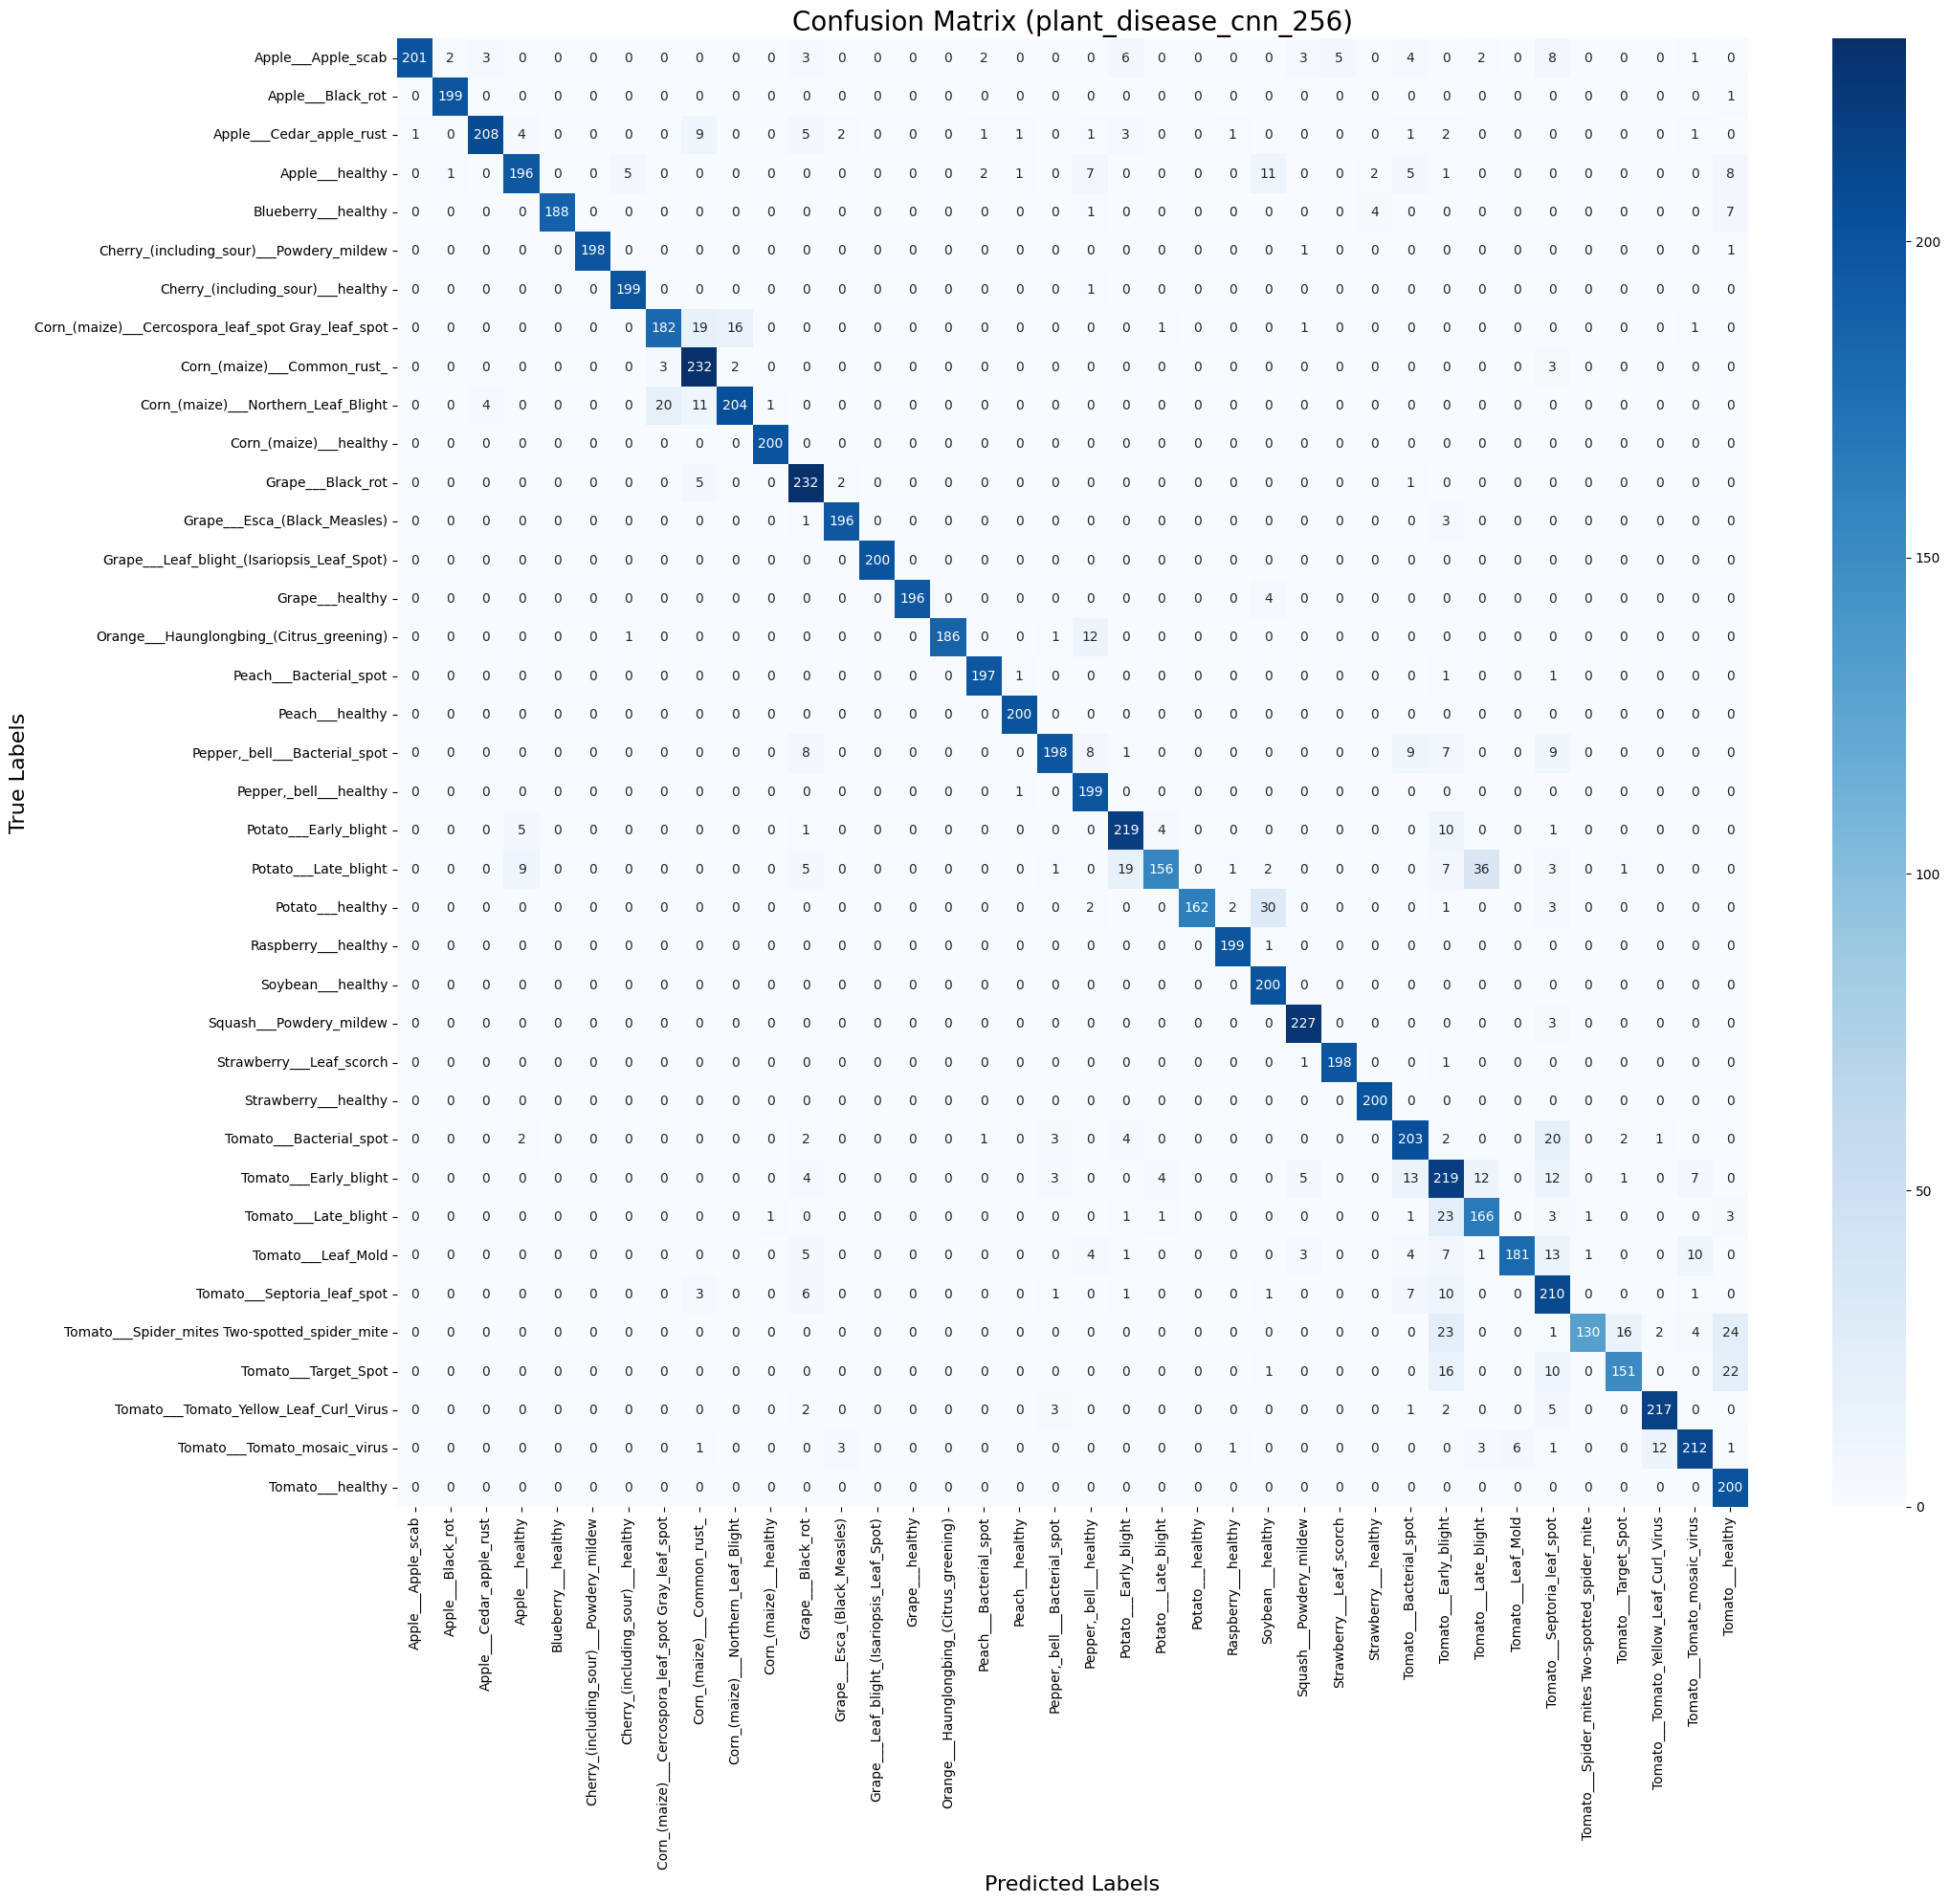


=== Classification Report (Precision / Recall / F1-score) ===

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.84      0.91       240
                                 Apple___Black_rot       0.99      0.99      0.99       200
                          Apple___Cedar_apple_rust       0.97      0.87      0.91       240
                                   Apple___healthy       0.91      0.82      0.86       239
                               Blueberry___healthy       1.00      0.94      0.97       200
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       200
                 Cherry_(including_sour)___healthy       0.97      0.99      0.98       200
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.83      0.86       220
                       Corn_(maize)___Common_rust_       0.83      0.97      0.89       240
               

<Figure size 640x480 with 0 Axes>

In [12]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === 1. Load model đã huấn luyện ===
model = load_model("/kaggle/working/plant_disease_cnn_256.h5")

# === 2. Tạo generator cho tập validation ===
val_datagen = ImageDataGenerator(rescale=1./255)

val_gen_noshuffle = val_datagen.flow_from_directory(
    val_dir,                
    target_size=(256, 256), # đúng kích thước model
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

# === 3. Dự đoán ===
pred_probs = model.predict(val_gen_noshuffle, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_gen_noshuffle.classes
class_labels = list(val_gen_noshuffle.class_indices.keys())

# === 4. Tạo ma trận nhầm lẫn ===
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(22, 20))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix (plant_disease_cnn_256)', fontsize=20)
plt.xlabel('Predicted Labels', fontsize=16)
plt.ylabel('True Labels', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# === 5. Báo cáo kết quả dạng chữ ===
print("\n=== Classification Report (Precision / Recall / F1-score) ===\n")
report_text = classification_report(true_classes, pred_classes, target_names=class_labels)
print(report_text)

# === 6. (Tùy chọn) Lưu lại để không bị mất nữa ===
with open("/kaggle/working/classification_report.txt", "w") as f:
    f.write(report_text)

plt.savefig("/kaggle/working/confusion_matrix.png")